In [16]:
import os
import sys
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    matthews_corrcoef, roc_curve, auc
)
from sklearn.metrics import cohen_kappa_score
from IPython.display import display
from transformers import AutoTokenizer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')


# Paths
BASE_DIR = Path('/mnt/storage/SLIIT/research/R26-IT-036')
DATA_DIR = BASE_DIR / 'data/Stress header/processed'
MODELS_DIR = BASE_DIR / 'models/c3_text_stressor_distortion/Stress header'
TRAIN_DIR = BASE_DIR / 'ai_components/c3_text_stressor_distortion/Stress header/train'
OUTPUT_DIR = BASE_DIR / 'reports' / 'c3_text_stressor_distortion' / 'Stress header' / 'evaluation' / 'error_analysis'
PLOTS_DIR = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(TRAIN_DIR))

from config import Config
from model import DualHeadStressModel
from utils import compute_metrics, compute_head1b_metrics, save_results

print(' Imports loaded')
print(f' Data dir   : {DATA_DIR}')
print(f' Models dir : {MODELS_DIR}')
print(f' Output dir  : {OUTPUT_DIR}')

# Load metadata and test data
with open(DATA_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

max_len = metadata.get('models', {}).get('BERT', {}).get('max_len', Config.BASE_HYPERPARAMS['MAX_LEN'])

test_df = pd.read_csv(DATA_DIR / 'dreaddit_test.csv')
print(f' Test set shape: {test_df.shape}')
print(' Columns:', test_df.columns.tolist())
print('\nLabel distribution:')
display(test_df['label'].value_counts().rename('count').to_frame())
print('\nSubreddit distribution:')
display(test_df['subreddit_label'].value_counts().rename('count').to_frame())

 Imports loaded
 Data dir   : /mnt/storage/SLIIT/research/R26-IT-036/data/Stress header/processed
 Models dir : /mnt/storage/SLIIT/research/R26-IT-036/models/c3_text_stressor_distortion/Stress header
 Output dir  : /mnt/storage/SLIIT/research/R26-IT-036/reports/c3_text_stressor_distortion/Stress header/evaluation/error_analysis
 Test set shape: (715, 9)
 Columns: ['text', 'text_for_bert', 'text_for_mentalbert', 'text_for_deberta', 'label', 'subreddit', 'subreddit_label', 'confidence', 'sentiment']

Label distribution:


,count
label,
1,369
0,346



Subreddit distribution:


,count
subreddit_label,
1,147
7,142
6,127
3,72
9,70
2,66
5,52
0,19
8,14


In [17]:
# Model configuration
model_configs = {
    'BERT': {
        'type': 'transformer',
        'hf_id': metadata['models']['BERT']['hf_id'],
        'text_col': metadata['models']['BERT']['text_col'],
        'model_path': MODELS_DIR / 'BERT_best.pt',
    },
    'MentalBERT': {
        'type': 'transformer',
        'hf_id': metadata['models']['MentalBERT']['hf_id'],
        'text_col': metadata['models']['MentalBERT']['text_col'],
        'model_path': MODELS_DIR / 'MentalBERT_best.pt',
    },
    'DeBERTa-v3': {
        'type': 'transformer',
        'hf_id': metadata['models']['DeBERTa-v3']['hf_id'],
        'text_col': metadata['models']['DeBERTa-v3']['text_col'],
        'model_path': MODELS_DIR / 'DeBERTa-v3_best.pt',
    },
    'LR': {
        'type': 'baseline',
        'model_path': MODELS_DIR / 'baseline_LR.pkl',
        'text_col': metadata['ml_baselines']['LR']['text_col'],
    },
    'SVM': {
        'type': 'baseline',
        'model_path': MODELS_DIR / 'baseline_SVM.pkl',
        'text_col': metadata['ml_baselines']['SVM']['text_col'],
    },
}

loaded_models = {}
for model_name, cfg in model_configs.items():
    try:
        print(f'\n→ Loading {model_name}...')
        if cfg['type'] == 'transformer':
            tokenizer = AutoTokenizer.from_pretrained(cfg['hf_id'])
            model = DualHeadStressModel(
                hf_id=cfg['hf_id'],
                num_subreddit_labels=metadata['num_labels']['head1b'],
                num_binary_labels=metadata['num_labels']['head1a'],
                dropout=Config.BASE_HYPERPARAMS['dropout'],
                head_dropout=Config.BASE_HYPERPARAMS['head_dropout'],
                intermediate=Config.BASE_HYPERPARAMS['intermediate'],
            )
            state_dict = torch.load(cfg['model_path'], map_location='cpu')
            model.load_state_dict(state_dict)
            model = model.to(Config.DEVICE).eval()
            loaded_models[model_name] = {
                'type': 'transformer',
                'model': model,
                'tokenizer': tokenizer,
                'text_col': cfg['text_col'],
                'hf_id': cfg['hf_id'],
                'path': str(cfg['model_path']),
            }
        else:
            with open(cfg['model_path'], 'rb') as f:
                bundle = pickle.load(f)
            loaded_models[model_name] = {
                'type': 'baseline',
                'model': bundle.get('model', bundle),
                'vectorizer': bundle.get('vectorizer'),
                'text_col': cfg['text_col'],
                'path': str(cfg['model_path']),
            }
        print(f'   Loaded {model_name}')
    except Exception as e:
        print(f'   Failed to load {model_name}: {e}')

print(f'\n Total loaded models: {len(loaded_models)}')
print(' Models:', list(loaded_models.keys()))


→ Loading BERT...
   Loaded BERT

→ Loading MentalBERT...


Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Loaded MentalBERT

→ Loading DeBERTa-v3...
   Loaded DeBERTa-v3

→ Loading LR...
   Loaded LR

→ Loading SVM...
   Loaded SVM

 Total loaded models: 5
 Models: ['BERT', 'MentalBERT', 'DeBERTa-v3', 'LR', 'SVM']


In [18]:
# Evaluation helpers
def compute_binary_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred),
    }
    if y_prob is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        except Exception:
            metrics['roc_auc'] = np.nan
    return metrics


def classify_error_type(true_label, pred_label):
    if true_label == 1 and pred_label == 0:
        return 'false_negative'
    if true_label == 0 and pred_label == 1:
        return 'false_positive'
    return 'correct'


def evaluate_transformer(model_info, df, batch_size=32):
    model = model_info['model']
    tokenizer = model_info['tokenizer']
    text_col = model_info['text_col']

    rows = []
    model.eval()

    for start in range(0, len(df), batch_size):
        batch = df.iloc[start:start + batch_size]
        texts = batch[text_col].fillna('').tolist()
        enc = tokenizer(
            texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        input_ids = enc['input_ids'].to(Config.DEVICE)
        attention_mask = enc['attention_mask'].to(Config.DEVICE)

        with torch.no_grad():
            logits_1a, logits_1b = model(input_ids, attention_mask)
            probs_1a = torch.softmax(logits_1a, dim=1)[:, 1]
            probs_1b = torch.softmax(logits_1b, dim=1)

        pred_1a = logits_1a.argmax(dim=1).cpu().numpy()
        pred_1b = logits_1b.argmax(dim=1).cpu().numpy()
        prob_1a = probs_1a.cpu().numpy()
        conf_1a = torch.softmax(logits_1a, dim=1).max(dim=1).values.cpu().numpy()
        conf_1b = probs_1b.max(dim=1).values.cpu().numpy()

        for i, idx in enumerate(batch.index):
            row = df.loc[idx].to_dict()
            row.update({
                'model_pred': int(pred_1a[i]),
                'model_prob': float(prob_1a[i]),
                'model_confidence': float(conf_1a[i]),
                'subreddit_pred': int(pred_1b[i]),
                'subreddit_confidence': float(conf_1b[i]),
            })
            rows.append(row)

    pred_df = pd.DataFrame(rows)
    pred_df['error_type'] = pred_df.apply(lambda r: classify_error_type(r['label'], r['model_pred']), axis=1)
    pred_df['is_correct'] = pred_df['error_type'] == 'correct'
    pred_df['is_error'] = ~pred_df['is_correct']
    pred_df['error_margin'] = np.abs(pred_df['model_prob'] - 0.5) * 2
    pred_df['correct_subreddit'] = pred_df['subreddit_label'] == pred_df['subreddit_pred']
    return pred_df


def evaluate_baseline(model_info, df):
    model = model_info['model']
    vectorizer = model_info['vectorizer']
    X = vectorizer.transform(df['text'].fillna('').tolist())

    preds = model.predict(X)
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X)[:, 1]
        conf = np.max(model.predict_proba(X), axis=1)
    elif hasattr(model, 'decision_function'):
        decision = model.decision_function(X)
        probs = 1 / (1 + np.exp(-decision))
        conf = np.abs(probs - 0.5) * 2
    else:
        probs = None
        conf = np.ones(len(df)) * 0.5

    pred_df = df.copy()
    pred_df['model_pred'] = preds.astype(int)
    pred_df['model_prob'] = probs if probs is None else probs.astype(float)
    pred_df['model_confidence'] = conf.astype(float)
    pred_df['error_type'] = pred_df.apply(lambda r: classify_error_type(r['label'], r['model_pred']), axis=1)
    pred_df['is_correct'] = pred_df['error_type'] == 'correct'
    pred_df['is_error'] = ~pred_df['is_correct']
    pred_df['error_margin'] = np.abs(pred_df['model_prob'] - 0.5) * 2 if probs is not None else 0.0
    return pred_df


def summarize_errors(pred_df):
    total = len(pred_df)
    errors = int(pred_df['is_error'].sum())
    fp = int((pred_df['error_type'] == 'false_positive').sum())
    fn = int((pred_df['error_type'] == 'false_negative').sum())
    y_true = pred_df['label'].tolist()
    y_pred = pred_df['model_pred'].tolist()
    y_prob = pred_df['model_prob'].tolist() if 'model_prob' in pred_df else None
    metrics = compute_binary_metrics(y_true, y_pred, y_prob)
    metrics.update({
        'total_samples': total,
        'errors': errors,
        'error_rate': errors / total if total else 0.0,
        'false_positives': fp,
        'false_negatives': fn,
        'mean_wrong_confidence': float(pred_df.loc[pred_df['is_error'], 'model_confidence'].mean()) if errors else 0.0,
        'mean_correct_confidence': float(pred_df.loc[pred_df['is_correct'], 'model_confidence'].mean()) if total - errors else 0.0,
    })
    return metrics


In [19]:
# Error Analysis
analysis_results = {}
all_pred_frames = {}

for model_name, info in loaded_models.items():
    print('\n' + '=' * 80)
    print(f"Evaluating {model_name} [{info['type']}]")
    print('=' * 80)

    if info['type'] == 'transformer':
        pred_df = evaluate_transformer(info, test_df)
    else:
        pred_df = evaluate_baseline(info, test_df)

    metrics = summarize_errors(pred_df)
    analysis_results[model_name] = {
        'model_name': model_name,
        'model_type': info['type'],
        'path': info['path'],
        'metrics': metrics,
        'error_counts': pred_df['error_type'].value_counts().to_dict(),
    }
    all_pred_frames[model_name] = pred_df

    print(f"Accuracy   : {metrics['accuracy']:.4f}")
    print(f"Precision  : {metrics['precision']:.4f}")
    print(f"Recall     : {metrics['recall']:.4f}")
    print(f"F1-Score   : {metrics['f1']:.4f}")
    print(f"MCC        : {metrics['mcc']:.4f}")
    if not np.isnan(metrics.get('roc_auc', np.nan)):
        print(f"ROC-AUC    : {metrics['roc_auc']:.4f}")
    print(f"Errors     : {metrics['errors']} / {metrics['total_samples']} ({metrics['error_rate']:.2%})")
    print(f"FP / FN    : {metrics['false_positives']} / {metrics['false_negatives']}")

combined_df = test_df.copy().reset_index(drop=True)
for model_name, pred_df in all_pred_frames.items():
    pred_df = pred_df.reset_index(drop=True)
    combined_df[f'{model_name}_pred'] = pred_df['model_pred']
    combined_df[f'{model_name}_prob'] = pred_df['model_prob']
    combined_df[f'{model_name}_conf'] = pred_df['model_confidence']
    combined_df[f'{model_name}_error'] = pred_df['is_error']
    combined_df[f'{model_name}_error_type'] = pred_df['error_type']

print('\n Combined prediction frame created')
print(' Shape:', combined_df.shape)

# Save raw results
save_results(analysis_results, OUTPUT_DIR / 'error_analysis_results.json')
combined_df.to_csv(OUTPUT_DIR / 'combined_predictions.csv', index=False)
print(' Saved: error_analysis_results.json')
print(' Saved: combined_predictions.csv')


Evaluating BERT [transformer]
Accuracy   : 0.7916
Precision  : 0.7895
Recall     : 0.8130
F1-Score   : 0.8011
MCC        : 0.5826
ROC-AUC    : 0.8749
Errors     : 149 / 715 (20.84%)
FP / FN    : 80 / 69

Evaluating MentalBERT [transformer]
Accuracy   : 0.7916
Precision  : 0.7764
Recall     : 0.8374
F1-Score   : 0.8057
MCC        : 0.5836
ROC-AUC    : 0.8922
Errors     : 149 / 715 (20.84%)
FP / FN    : 89 / 60

Evaluating DeBERTa-v3 [transformer]
Accuracy   : 0.8168
Precision  : 0.8051
Recall     : 0.8509
F1-Score   : 0.8274
MCC        : 0.6336
ROC-AUC    : 0.8927
Errors     : 131 / 715 (18.32%)
FP / FN    : 76 / 55

Evaluating LR [baseline]
Accuracy   : 0.6671
Precision  : 0.6184
Recall     : 0.9268
F1-Score   : 0.7419
MCC        : 0.3784
ROC-AUC    : 0.7982
Errors     : 238 / 715 (33.29%)
FP / FN    : 211 / 27

Evaluating SVM [baseline]
Accuracy   : 0.6517
Precision  : 0.6042
Recall     : 0.9431
F1-Score   : 0.7365
MCC        : 0.3588
ROC-AUC    : 0.8044
Errors     : 249 / 715 (34.83

## Summary of Error Analysis

In [20]:
summary_rows = []
for model_name, result in analysis_results.items():
    m = result['metrics']
    summary_rows.append({
        'Model': model_name,
        'Type': result['model_type'],
        'Accuracy': m['accuracy'],
        'Precision': m['precision'],
        'Recall': m['recall'],
        'F1': m['f1'],
        'MCC': m['mcc'],
        'ROC-AUC': m.get('roc_auc', np.nan),
        'Errors': m['errors'],
        'Error Rate': m['error_rate'],
        'FP': m['false_positives'],
        'FN': m['false_negatives'],
        'Wrong Confidence': m['mean_wrong_confidence'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('F1', ascending=False).reset_index(drop=True)
print('\n' + '=' * 100)
print('ERROR ANALYSIS SUMMARY (STRESS DETECTION)')
print('=' * 100)
display(summary_df)

# Transformer-only subreddit analysis
transformer_rows = []
for model_name, pred_df in all_pred_frames.items():
    if analysis_results[model_name]['model_type'] != 'transformer':
        continue
    correct = pred_df['correct_subreddit'].mean()
    sub_acc = float(correct)
    sub_f1 = f1_score(pred_df['subreddit_label'], pred_df['subreddit_pred'], average='macro', zero_division=0)
    transformer_rows.append({
        'Model': model_name,
        'Subreddit Accuracy': sub_acc,
        'Subreddit F1-Macro': sub_f1,
        'Subreddit Wrong': int((~pred_df['correct_subreddit']).sum()),
    })

subreddit_df = pd.DataFrame(transformer_rows).sort_values('Subreddit F1-Macro', ascending=False).reset_index(drop=True)
print('\n' + '=' * 100)
print('TRANSFORMER SUBREDDIT ERROR SUMMARY')
print('=' * 100)
display(subreddit_df)

# Save tables
summary_df.to_csv(OUTPUT_DIR / 'error_summary.csv', index=False)
subreddit_df.to_csv(OUTPUT_DIR / 'subreddit_error_summary.csv', index=False)
print('\n Saved: error_summary.csv')
print(' Saved: subreddit_error_summary.csv')


ERROR ANALYSIS SUMMARY (STRESS DETECTION)


,Model,Type,Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Errors,Error Rate,FP,FN,Wrong Confidence
0,DeBERTa-v3,transformer,0.816783,0.805128,0.850949,0.827404,0.633592,0.892711,131,0.183217,76,55,0.840782
1,MentalBERT,transformer,0.791608,0.776382,0.837398,0.805737,0.583630,0.892155,149,0.208392,89,60,0.722033
2,BERT,transformer,0.791608,0.789474,0.813008,0.801068,0.582648,0.874947,149,0.208392,80,69,0.747485
3,LR,baseline,0.667133,0.618445,0.926829,0.741866,0.378437,0.798213,238,0.332867,211,27,0.671359
4,SVM,baseline,0.651748,0.604167,0.943089,0.736508,0.358798,0.804424,249,0.348252,228,21,0.782067



TRANSFORMER SUBREDDIT ERROR SUMMARY


,Model,Subreddit Accuracy,Subreddit F1-Macro,Subreddit Wrong
0,BERT,0.562238,0.477866,313
1,MentalBERT,0.566434,0.459917,310
2,DeBERTa-v3,0.254545,0.183417,533



 Saved: error_summary.csv
 Saved: subreddit_error_summary.csv


## Visualization of Error Analysis

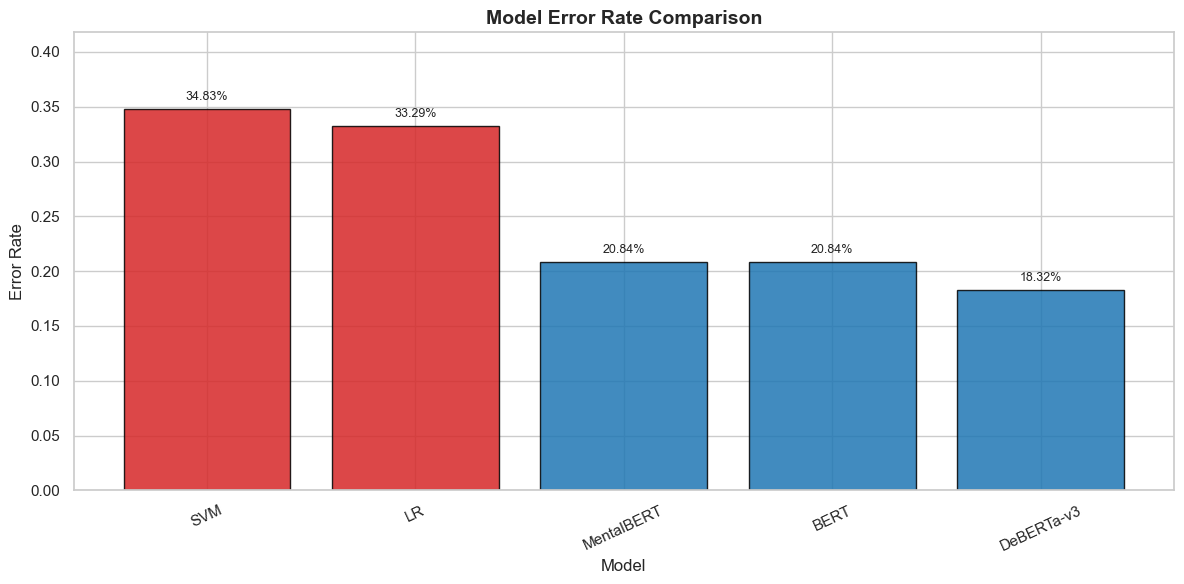

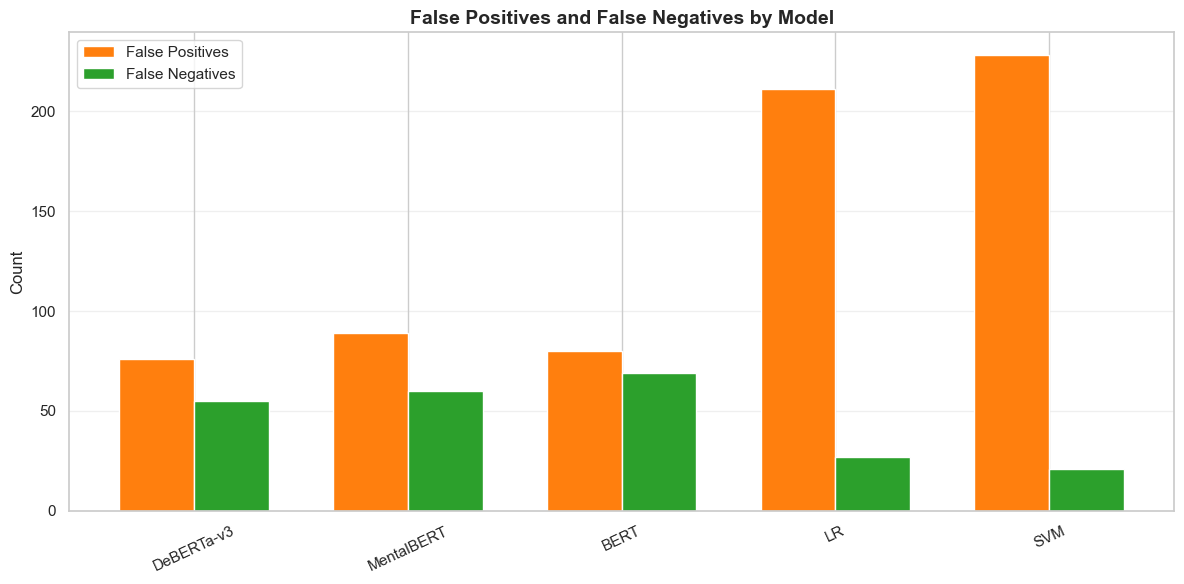

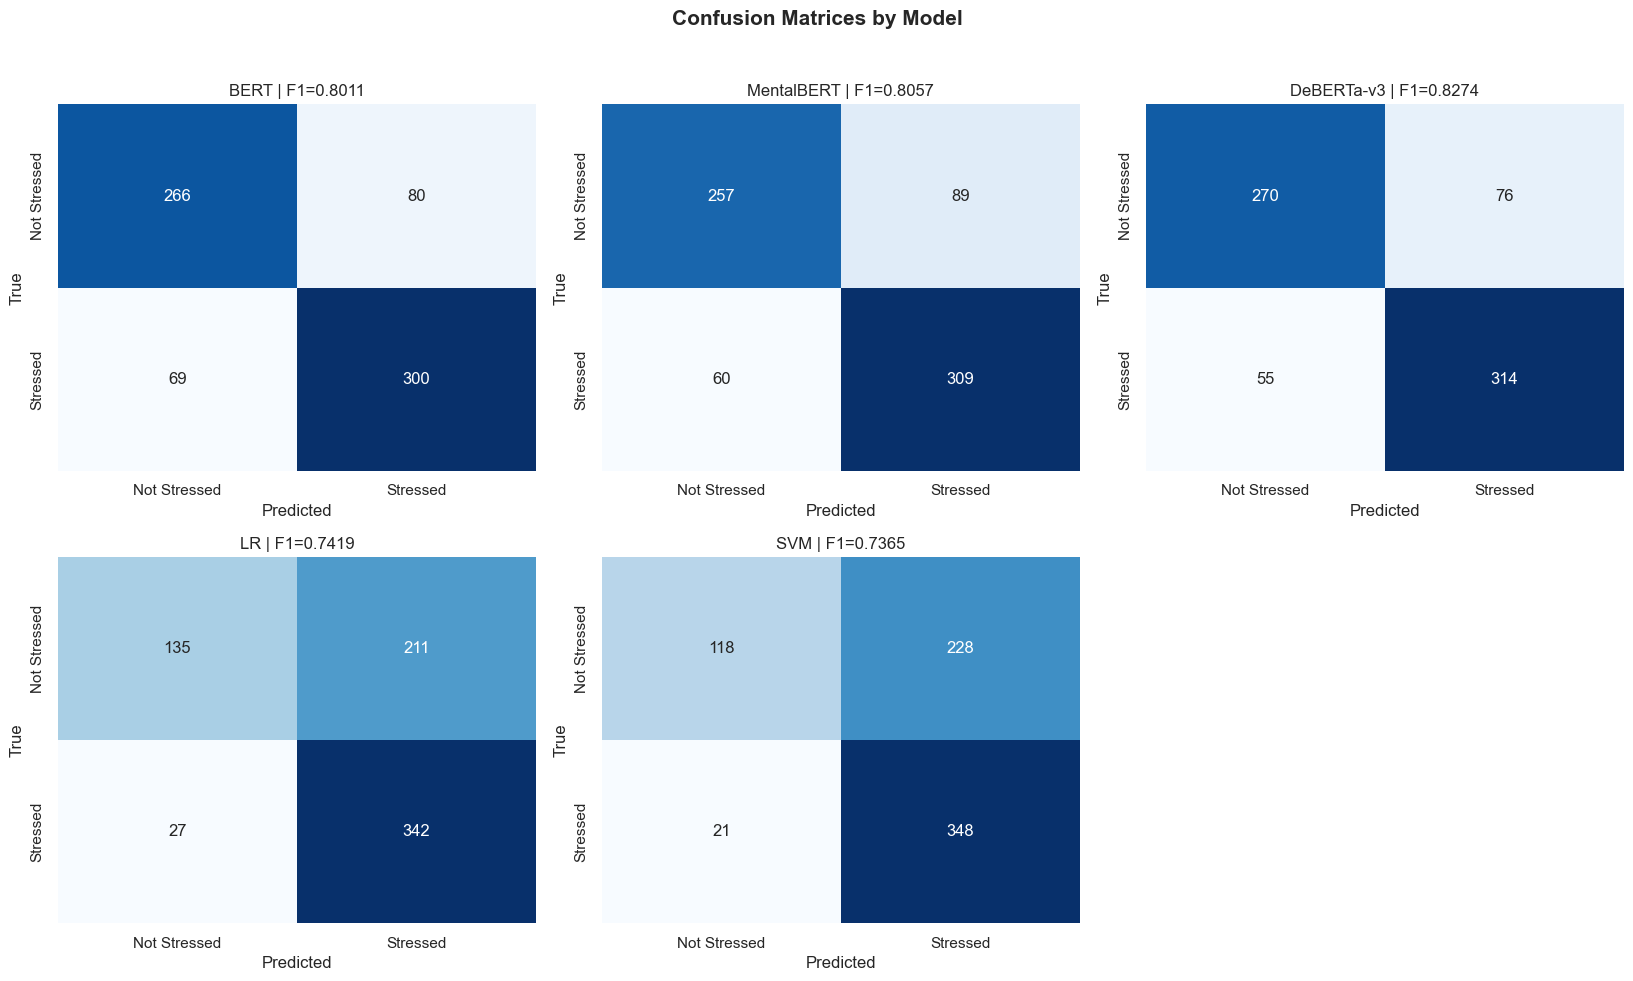

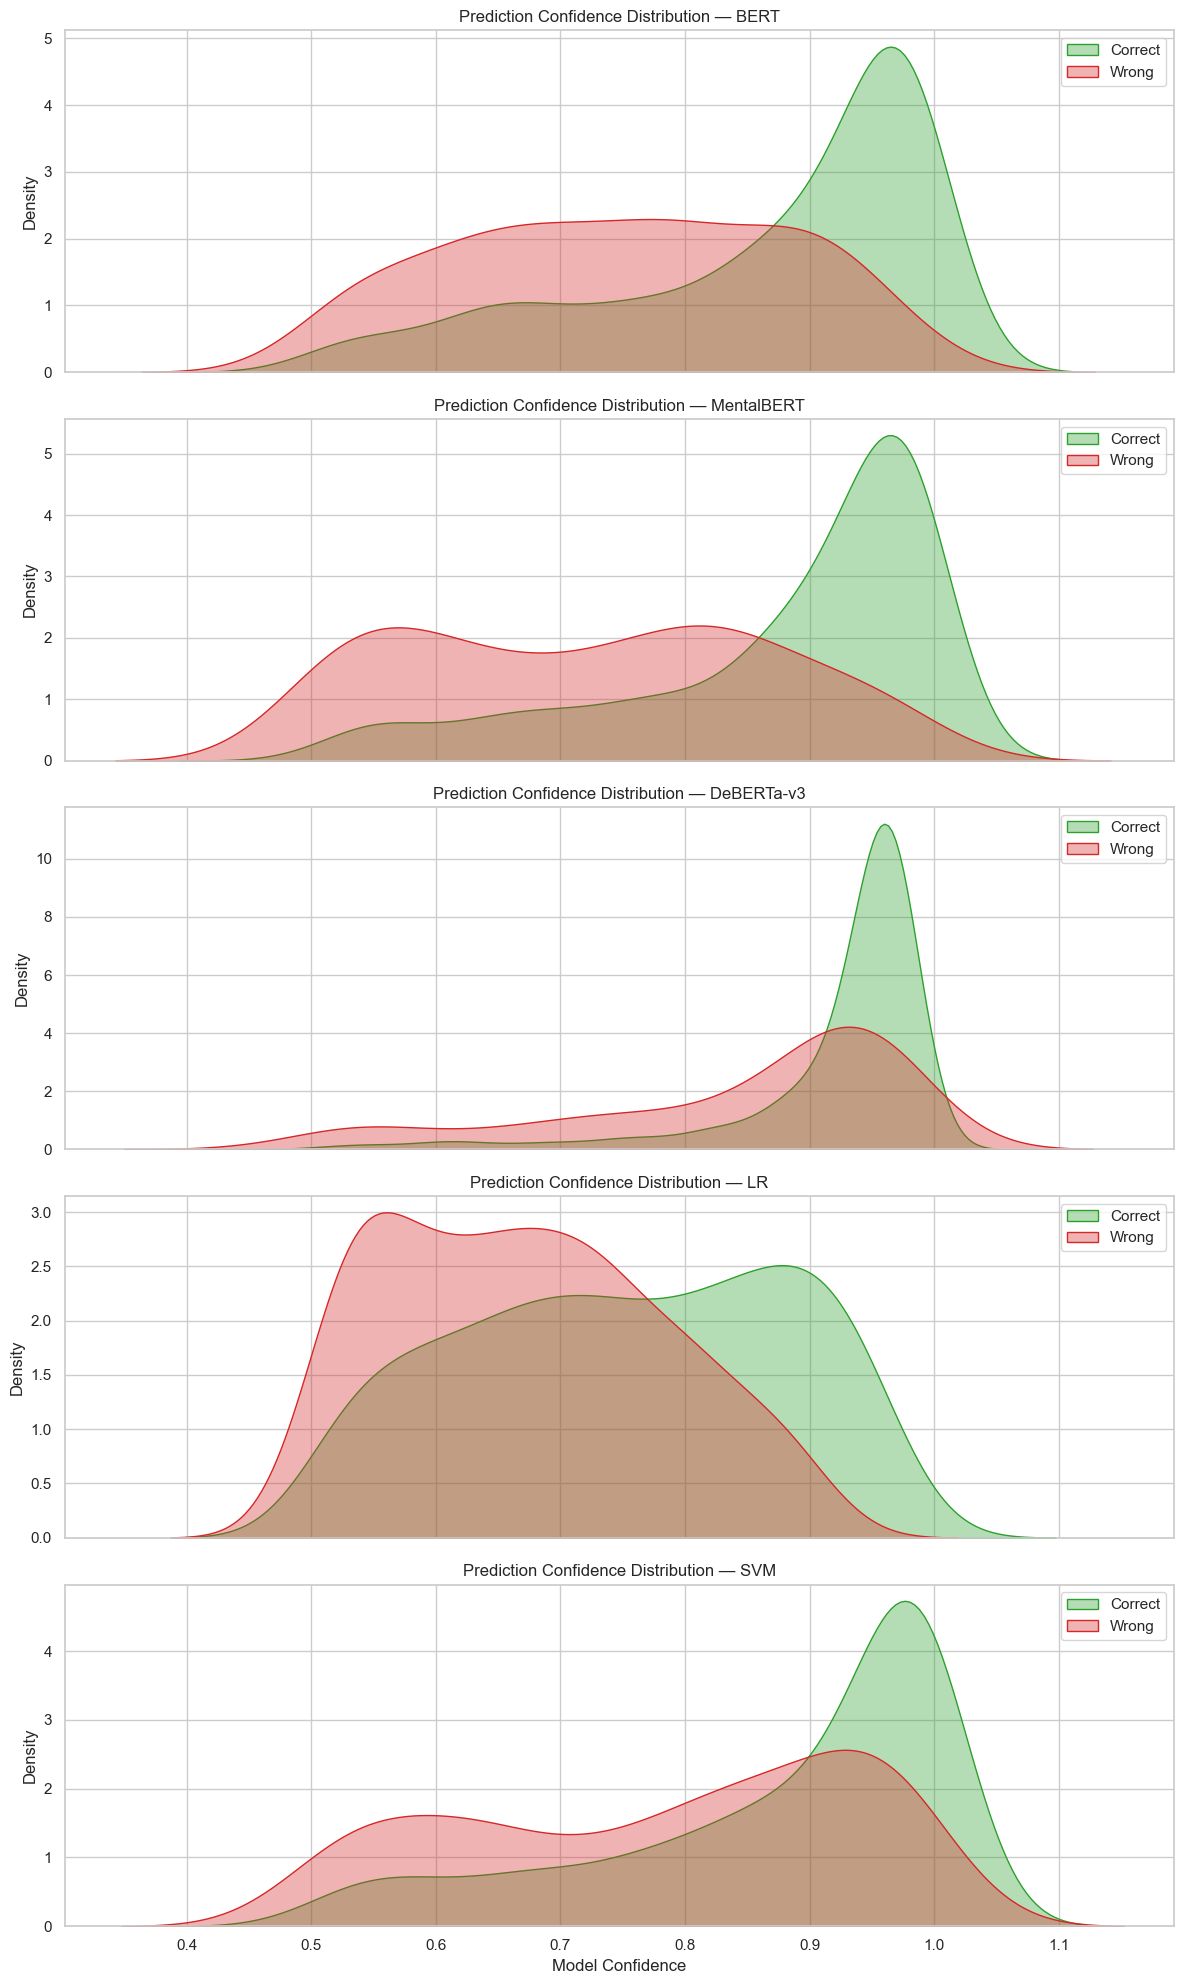

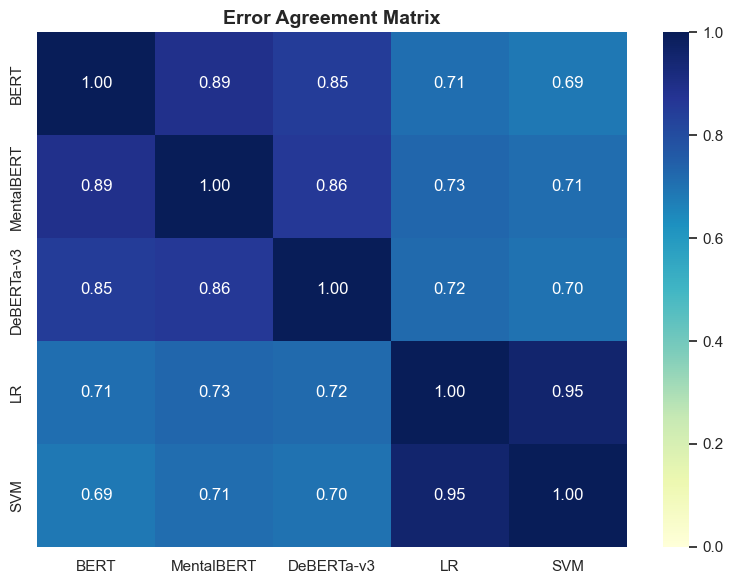

 Saved visualization files to: /mnt/storage/SLIIT/research/R26-IT-036/reports/c3_text_stressor_distortion/Stress header/evaluation/error_analysis/plots


In [21]:
# Error rate comparison
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = summary_df.sort_values('Error Rate', ascending=False)
colors = ['#d62728' if t == 'baseline' else '#1f77b4' for t in plot_df['Type']]
bars = ax.bar(plot_df['Model'], plot_df['Error Rate'], color=colors, edgecolor='black', alpha=0.85)
ax.set_title('Model Error Rate Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Error Rate')
ax.set_xlabel('Model')
ax.set_ylim(0, max(plot_df['Error Rate'].max() * 1.2, 0.05))
ax.tick_params(axis='x', rotation=25)
for bar, val in zip(bars, plot_df['Error Rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{val:.2%}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '1_error_rate_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# False positives vs false negatives
fig, ax = plt.subplots(figsize=(12, 6))
fp = summary_df['FP'].values
fn = summary_df['FN'].values
x = np.arange(len(summary_df))
width = 0.35
ax.bar(x - width/2, fp, width, label='False Positives', color='#ff7f0e')
ax.bar(x + width/2, fn, width, label='False Negatives', color='#2ca02c')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Model'], rotation=25)
ax.set_title('False Positives and False Negatives by Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '2_fp_fn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion matrices for all models
n_models = len(all_pred_frames)
ncols = min(3, n_models)
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.8 * nrows))
axes = np.array(axes).reshape(-1)
for i, (model_name, pred_df) in enumerate(all_pred_frames.items()):
    cm = confusion_matrix(pred_df['label'], pred_df['model_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
        xticklabels=['Not Stressed', 'Stressed'],
        yticklabels=['Not Stressed', 'Stressed']
    )
    axes[i].set_title(f'{model_name} | F1={analysis_results[model_name]["metrics"]["f1"]:.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Confusion Matrices by Model', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '3_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Confidence distribution for correct vs wrong predictions
fig, axes = plt.subplots(len(all_pred_frames), 1, figsize=(12, 4 * len(all_pred_frames)), sharex=True)
if len(all_pred_frames) == 1:
    axes = [axes]
for ax, (model_name, pred_df) in zip(axes, all_pred_frames.items()):
    correct_conf = pred_df.loc[pred_df['is_correct'], 'model_confidence']
    wrong_conf = pred_df.loc[pred_df['is_error'], 'model_confidence']
    if len(correct_conf):
        sns.kdeplot(correct_conf, fill=True, ax=ax, label='Correct', color='#2ca02c', alpha=0.35)
    if len(wrong_conf):
        sns.kdeplot(wrong_conf, fill=True, ax=ax, label='Wrong', color='#d62728', alpha=0.35)
    ax.set_title(f'Prediction Confidence Distribution — {model_name}')
    ax.set_xlabel('Model Confidence')
    ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '4_confidence_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Error overlap matrix (pairwise disagreement share)
model_names = list(all_pred_frames.keys())
overlap = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
for m1 in model_names:
    e1 = all_pred_frames[m1]['is_error'].astype(int).values
    for m2 in model_names:
        e2 = all_pred_frames[m2]['is_error'].astype(int).values
        overlap.loc[m1, m2] = np.mean(e1 == e2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(overlap, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax, vmin=0, vmax=1)
ax.set_title('Error Agreement Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '5_error_agreement_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(' Saved visualization files to:', PLOTS_DIR)

In [22]:
# Deep analysis of top errors 
def show_top_errors(pred_df, model_name, n=10):
    print(f"\n{'='*100}")
    print(f'{model_name} — Top False Positives')
    print('=' * 100)
    fp_df = pred_df[pred_df['error_type'] == 'false_positive'].copy()
    if len(fp_df):
        cols = ['text', 'label', 'model_pred', 'model_prob', 'model_confidence', 'subreddit_label']
        display(fp_df.sort_values('model_confidence', ascending=False)[cols].head(n))
    else:
        print('No false positives')

    print(f"\n{'='*100}")
    print(f'{model_name} — Top False Negatives')
    print('=' * 100)
    fn_df = pred_df[pred_df['error_type'] == 'false_negative'].copy()
    if len(fn_df):
        cols = ['text', 'label', 'model_pred', 'model_prob', 'model_confidence', 'subreddit_label']
        display(fn_df.sort_values('model_confidence', ascending=False)[cols].head(n))
    else:
        print('No false negatives')

for model_name, pred_df in all_pred_frames.items():
    show_top_errors(pred_df, model_name, n=8)

# Samples that every model gets wrong / every model gets right
error_cols = [f'{m}_error' for m in loaded_models.keys()]
combined_df['all_models_wrong'] = combined_df[error_cols].all(axis=1)
combined_df['all_models_correct'] = ~combined_df[error_cols].any(axis=1)
combined_df['wrong_model_count'] = combined_df[error_cols].sum(axis=1)

print(f"\n{'='*100}")
print('Hardest samples — wrong by all models')
print('=' * 100)
hardest = combined_df[combined_df['all_models_wrong']].copy()
if len(hardest):
    display(hardest[['text', 'label', 'subreddit_label'] + [f'{m}_pred' for m in loaded_models.keys()] + [f'{m}_prob' for m in loaded_models.keys()]].head(20))
else:
    print('No samples were misclassified by all models.')

print(f"\n{'='*100}")
print('Easiest samples — correct by all models')
print('=' * 100)
easiest = combined_df[combined_df['all_models_correct']].copy()
if len(easiest):
    display(easiest[['text', 'label', 'subreddit_label'] + [f'{m}_pred' for m in loaded_models.keys()]].head(20))
else:
    print('No samples were classified correctly by all models.')

combined_df.to_csv(OUTPUT_DIR / 'agreement_analysis.csv', index=False)
print('\n Saved: agreement_analysis.csv')


BERT — Top False Positives


,text,label,model_pred,model_prob,model_confidence,subreddit_label
50,None of the issues we discuss get addressed. 6...,0,1,0.983334,0.983334,7
269,He pretty much told me that he was angry and d...,0,1,0.978106,0.978106,6
199,I'm sorry if I didn't post this in the right p...,0,1,0.967967,0.967967,1
101,Best friend knows I have anxiety and I am alwa...,0,1,0.953096,0.953096,1
216,I sent a respectful email to my primary psychi...,0,1,0.948021,0.948021,9
684,He told me to never talk to him again and that...,0,1,0.930775,0.930775,7
91,I can't support their relationship on any leve...,0,1,0.926978,0.926978,3
376,"If he's the textbook abuser, she is the textbo...",0,1,0.920668,0.920668,3



BERT — Top False Negatives


,text,label,model_pred,model_prob,model_confidence,subreddit_label
174,He is our little angel and we are both gaga fo...,1,0,0.023898,0.976102,7
175,"We met about 2.5 years ago, both somewhat fres...",1,0,0.036514,0.963486,7
195,We've funnelled about 4k into saving our dog's...,1,0,0.046079,0.953921,2
139,"So I texted her a message saying “7:45” , I se...",1,0,0.047766,0.952234,7
359,"It’s getting up above 100 here, and I’d like t...",1,0,0.047888,0.952112,5
239,She's the first person I've ever really opened...,1,0,0.072970,0.927030,6
322,Then I came home. My Mom pointed it out f...,1,0,0.085004,0.914996,6
105,Do you huddle up in the corner of some obscure...,1,0,0.087010,0.912990,5



MentalBERT — Top False Positives


...


Hardest samples — wrong by all models


,text,label,subreddit_label,BERT_pred,MentalBERT_pred,DeBERTa-v3_pred,LR_pred,SVM_pred,BERT_prob,MentalBERT_prob,DeBERTa-v3_prob,LR_prob,SVM_prob
47,I'll try to keep this short. I've never been a...,0,7,1,1,1,1,1,0.701224,0.917595,0.945563,0.805375,0.944752
50,None of the issues we discuss get addressed. 6...,0,7,1,1,1,1,1,0.983334,0.960467,0.951341,0.895817,0.995228
56,"Like, I don't think they happen if I distract ...",0,6,1,1,1,1,1,0.884656,0.927688,0.921765,0.870243,0.983427
61,That's why I've come to you guys. \- If the fo...,0,1,1,1,1,1,1,0.724007,0.655468,0.951400,0.726282,0.878155
83,"Please, I'm NOT looking for any handouts. That...",0,2,1,1,1,1,1,0.910482,0.569773,0.725106,0.643516,0.797527
99,Hi everyone. For a few months now I haven't be...,0,9,1,1,1,1,1,0.753298,0.789383,0.955866,0.609898,0.606142
101,Best friend knows I have anxiety and I am alwa...,0,1,1,1,1,1,1,0.953096,0.908361,0.817769,0.724107,0.918028
127,I have a question about my ex who has a past o...,0,3,1,1,1,1,1,0.857614,0.817624,0.820398,0.672079,0.892433
166,"Hi PTSD forums, Selective mutism has been some...",0,6,1,1,1,1,1,0.832452,0.818480,0.952961,0.564836,0.644195
174,He is our little angel and we are both gaga fo...,1,7,0,0,0,0,0,0.023898,0.028667,0.038844,0.216096,0.051860



Easiest samples — correct by all models


,text,label,subreddit_label,BERT_pred,MentalBERT_pred,DeBERTa-v3_pred,LR_pred,SVM_pred
2,We'd be saving so much money with this new hou...,1,6,1,1,1,1,1
3,"My ex used to shoot back with ""Do you want me ...",1,6,1,1,1,1,1
5,Thanks. Edit 1 - Fuel Receipt As Requested. <u...,0,2,0,0,0,0,0
6,"When moving into their tiny house, they would ...",0,5,0,0,0,0,0
7,"More specifically, for example, I live with ro...",1,1,1,1,1,1,1
8,Long story short my family in NE Ohio is abusi...,1,0,1,1,1,1,1
10,I've always hated nail files. Somehow that's a...,1,9,1,1,1,1,1
11,"Yesterday afternoon, two black males attacked ...",1,6,1,1,1,1,1
13,He’s abused my dog in the past and I’ve no dou...,1,3,1,1,1,1,1
14,the only thing I ever want is just to be in hi...,1,3,1,1,1,1,1



 Saved: agreement_analysis.csv


In [23]:
# Final report
report_lines = []
report_lines.append('ERROR ANALYSIS REPORT')
report_lines.append('=' * 80)
report_lines.append(f'Test samples: {len(test_df)}')
report_lines.append('')

report_lines.append('MODEL SUMMARY')
report_lines.append('-' * 80)
for _, row in summary_df.iterrows():
    report_lines.append(
        f"{row['Model']:12s} | {row['Type']:11s} | "
        f"Acc={row['Accuracy']:.4f} | F1={row['F1']:.4f} | "
        f"Err={row['Error Rate']:.2%} | FP={int(row['FP'])} | FN={int(row['FN'])}"
    )

report_lines.append('')
report_lines.append('TRANSFORMER SUBREDDIT SUMMARY')
report_lines.append('-' * 80)
if len(subreddit_df):
    for _, row in subreddit_df.iterrows():
        report_lines.append(
            f"{row['Model']:12s} | Acc={row['Subreddit Accuracy']:.4f} | "
            f"F1={row['Subreddit F1-Macro']:.4f} | Wrong={int(row['Subreddit Wrong'])}"
        )
else:
    report_lines.append('No transformer subreddit results available.')

report_lines.append('')
report_lines.append('HARD MODEL AGREEMENT STATS')
report_lines.append('-' * 80)
report_lines.append(f"All models correct: {int(combined_df['all_models_correct'].sum())}")
report_lines.append(f"All models wrong   : {int(combined_df['all_models_wrong'].sum())}")
report_lines.append(f"Avg wrong-model count per sample: {combined_df['wrong_model_count'].mean():.2f}")

report_path = OUTPUT_DIR / 'error_analysis_report.txt'
with open(report_path, 'w') as f:
    f.write('\n'.join(report_lines))